## Stellar Structure Modeling
### Isaac Moskowitz
### Professor Kevin Schlaufman, TA: Patrick McCreery

This notebook will walk through the steps necessary to solve the coupled system of ODEs that make the equations of stellar structure, to construct a zero-age main sequence (ZAMS) model of a star. The program is customizable, so the user can input any mass and composition they chose to model. For the purposes of this stellar structure calculation, we will be modeling the properties of a $1.6 M_{\odot}$ with solar composition. 

In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.integrate import odeint
import os
from tqdm import tqdm
from utils import *
from stellar_model import StellarStructure
import mesa_reader as mr # for reading MESA outputs and plotting them.

%load_ext autoreload
%reload_ext autoreload
%autoreload 2

SyntaxError: invalid decimal literal (utils.py, line 111)

In [ ]:
%config InlineBackend.figure_format='retina'
plt.rcParams.update({'axes.linewidth' : 1,
                     'ytick.major.width' : 1,
                     'ytick.minor.width' : 1,
                     'xtick.major.width' : 1,
                     'xtick.minor.width' : 1,
                     'xtick.labelsize': 10, 
                     'ytick.labelsize': 10,
                     'axes.labelsize': 12,
                     'font.family': 'Serif',
                     'figure.figsize': (10, 6)
                    })

### Opacity Table Interpolation
We will be using the OPAL opacity tables for solar composition ($X=0.70$, $Y=0.28$) to determine how the properties of a $1.6M_{\odot}$ star formed with similar composition to the Sun. 

In [ ]:
table_text = """
3.75  9.999 -0.922 -1.113 -1.321 -1.535 -1.747 -1.948 -2.117 -2.227 -2.241 -2.152 -1.987 -1.769 -1.515 -1.227 -0.895 -0.517 -0.105  0.308
3.80  9.999 -0.592 -0.667 -0.786 -0.936 -1.100 -1.261 -1.398 -1.479 -1.487 -1.414 -1.271 -1.086 -0.874 -0.642 -0.389 -0.107  0.214  0.575
3.85  9.999 -0.523 -0.516 -0.516 -0.532 -0.576 -0.636 -0.693 -0.722 -0.709 -0.645 -0.536 -0.389 -0.215 -0.019  0.196  0.431  0.692  0.983
3.90  9.999 -0.523 -0.502 -0.462 -0.396 -0.302 -0.199 -0.106 -0.029  0.041  0.115  0.204  0.313  0.446  0.603  0.782  0.983  1.208  1.456
3.95  9.999 -0.529 -0.510 -0.469 -0.387 -0.243 -0.034  0.221  0.464  0.654  0.791  0.899  0.997  1.101  1.220  1.360  1.524  1.713  1.926
4.00  9.999 -0.521 -0.512 -0.481 -0.407 -0.261 -0.023  0.301  0.667  1.007  1.268  1.453  1.585  1.693  1.796  1.909  2.040  2.193  2.368
4.05  9.999 -0.492 -0.488 -0.472 -0.417 -0.289 -0.061  0.273  0.681  1.107  1.494  1.799  2.013  2.166  2.285  2.392  2.503  2.628  2.771
4.10  9.999 -0.475 -0.465 -0.445 -0.397 -0.292 -0.095  0.214  0.616  1.067  1.521  1.929  2.257  2.495  2.663  2.791  2.903  3.014  3.134
4.15  9.999 -0.457 -0.445 -0.424 -0.377 -0.277 -0.094  0.182  0.551  0.988  1.457  1.924  2.348  2.687  2.933  3.107  3.240  3.353  3.464
4.20  9.999 -0.454 -0.432 -0.402 -0.354 -0.260 -0.089  0.175  0.524  0.934  1.389  1.872  2.346  2.770  3.109  3.350  3.525  3.659  3.774
4.25  9.999 -0.458 -0.435 -0.402 -0.346 -0.248 -0.085  0.162  0.499  0.908  1.355  1.829  2.314  2.790  3.207  3.528  3.760  3.934  4.069
4.30  9.999 -0.452 -0.431 -0.399 -0.346 -0.249 -0.084  0.163  0.492  0.897  1.351  1.827  2.308  2.801  3.263  3.655  3.954  4.174  4.345
4.35  9.999 -0.441 -0.420 -0.386 -0.334 -0.246 -0.092  0.150  0.486  0.898  1.357  1.840  2.337  2.833  3.313  3.754  4.114  4.384  4.593
4.40  9.999 -0.426 -0.406 -0.367 -0.310 -0.223 -0.081  0.148  0.480  0.903  1.377  1.876  2.378  2.886  3.383  3.848  4.253  4.570  4.809
4.45  9.999 -0.412 -0.391 -0.349 -0.280 -0.181 -0.035  0.185  0.506  0.924  1.407  1.922  2.438  2.959  3.466  3.950  4.382  4.734  5.003
4.50  9.999 -0.403 -0.378 -0.329 -0.247 -0.127  0.036  0.260  0.575  0.981  1.457  1.971  2.503  3.035  3.553  4.054  4.503  4.878  5.165
4.55  9.999 -0.402 -0.378 -0.332 -0.248 -0.106  0.094  0.349  0.672  1.072  1.535  2.037  2.570  3.107  3.635  4.145  4.606  4.993  5.285
4.60  9.999 -0.403 -0.379 -0.332 -0.251 -0.110  0.111  0.410  0.771  1.180  1.634  2.120  2.638  3.168  3.698  4.209  4.672  5.061  5.347
4.65  9.999 -0.406 -0.384 -0.343 -0.266 -0.126  0.099  0.416  0.815  1.261  1.723  2.200  2.697  3.210  3.728  4.228  4.684  5.068  5.349
4.70  9.999 -0.403 -0.384 -0.349 -0.282 -0.153  0.069  0.391  0.798  1.263  1.753  2.243  2.730  3.223  3.720  4.202  4.643  5.018  5.299
4.75  9.999 -0.403 -0.384 -0.348 -0.289 -0.175  0.030  0.345  0.752  1.217  1.712  2.219  2.717  3.203  3.681  4.143  4.569  4.938  5.222
4.80  9.999 -0.400 -0.382 -0.351 -0.294 -0.188 -0.001  0.290  0.685  1.147  1.641  2.151  2.660  3.154  3.626  4.074  4.488  4.848  5.136
4.85  9.999 -0.389 -0.370 -0.340 -0.288 -0.192 -0.017  0.257  0.627  1.076  1.570  2.081  2.591  3.092  3.570  4.015  4.420  4.772  5.057
4.90  9.999 -0.373 -0.355 -0.325 -0.275 -0.185 -0.025  0.233  0.587  1.018  1.505  2.019  2.534  3.038  3.521  3.970  4.370  4.712  4.986
4.95  9.999 -0.349 -0.329 -0.300 -0.250 -0.162 -0.010  0.233  0.573  0.992  1.467  1.976  2.496  3.001  3.486  3.939  4.334  4.662  4.913
5.00  9.999 -0.311 -0.292 -0.262 -0.214 -0.129  0.018  0.249  0.575  0.984  1.453  1.957  2.473  2.979  3.465  3.914  4.302  4.611  4.831
5.05  9.999 -0.243 -0.225 -0.198 -0.152 -0.070  0.070  0.290  0.601  0.996  1.456  1.954  2.464  2.967  3.446  3.884  4.258  4.542  4.731
5.10  9.999 -0.162 -0.140 -0.110 -0.068  0.008  0.144  0.355  0.650  1.029  1.472  1.959  2.462  2.955  3.417  3.833  4.184  4.443  4.610
5.15  9.999 -0.106 -0.063 -0.017  0.036  0.115  0.243  0.441  0.719  1.075  1.498  1.968  2.458  2.934  3.367  3.748  4.072  4.314  4.480
5.20  9.999 -0.082 -0.023  0.045  0.125  0.223  0.357  0.545  0.802  1.135  1.535  1.982  2.448  2.897  3.290  3.632  3.929  4.166  4.338
5.25  9.999 -0.099 -0.025  0.059  0.162  0.290  0.450  0.647  0.891  1.195  1.568  1.991  2.431  2.845  3.194  3.495  3.771  4.009  4.189
5.30  9.999 -0.178 -0.081  0.027  0.146  0.293  0.479  0.698  0.946  1.237  1.586  1.984  2.399  2.778  3.088  3.355  3.614  3.852  4.041
5.35  9.999 -0.273 -0.186 -0.069  0.076  0.248  0.452  0.692  0.960  1.251  1.581  1.957  2.349  2.699  2.979  3.220  3.464  3.698  3.901
5.40  9.999 -0.355 -0.287 -0.188 -0.051  0.136  0.368  0.635  0.927  1.235  1.561  1.916  2.284  2.612  2.872  3.094  3.326  3.554  9.999
5.45  9.999 -0.412 -0.367 -0.291 -0.174 -0.006  0.227  0.521  0.846  1.181  1.523  1.868  2.214  2.524  2.769  2.977  3.198  3.424  9.999
5.50  9.999 -0.439 -0.413 -0.366 -0.282 -0.139  0.076  0.372  0.729  1.103  1.467  1.816  2.148  2.441  2.671  2.872  3.082  3.308  9.999
5.55  9.999 -0.453 -0.438 -0.409 -0.353 -0.248 -0.061  0.223  0.596  1.008  1.402  1.760  2.086  2.365  2.583  2.775  2.980  9.999  9.999
5.60  9.999 -0.458 -0.449 -0.431 -0.395 -0.319 -0.172  0.086  0.464  0.904  1.330  1.703  2.025  2.294  2.503  2.690  2.890  9.999  9.999
5.65  9.999 -0.460 -0.455 -0.443 -0.418 -0.365 -0.252 -0.032  0.331  0.793  1.251  1.645  1.967  2.228  2.432  2.616  2.810  9.999  9.999
5.70  9.999 -0.462 -0.457 -0.448 -0.429 -0.391 -0.307 -0.128  0.203  0.671  1.163  1.581  1.909  2.166  2.367  2.551  9.999  9.999  9.999
5.75  9.999 -0.463 -0.459 -0.451 -0.437 -0.407 -0.341 -0.200  0.085  0.537  1.057  1.506  1.846  2.105  2.307  2.490  9.999  9.999  9.999
5.80  9.999 -0.464 -0.460 -0.453 -0.440 -0.414 -0.360 -0.244 -0.004  0.411  0.937  1.417  1.777  2.040  2.248  2.435  9.999  9.999  9.999
5.85  9.999 -0.464 -0.461 -0.454 -0.442 -0.418 -0.372 -0.271 -0.066  0.307  0.818  1.319  1.701  1.975  2.190  2.384  9.999  9.999  9.999
5.90  9.999 -0.463 -0.460 -0.455 -0.443 -0.422 -0.378 -0.288 -0.105  0.229  0.715  1.222  1.625  1.912  2.136  2.335  9.999  9.999  9.999
5.95  9.999 -0.461 -0.458 -0.453 -0.443 -0.423 -0.383 -0.298 -0.130  0.175  0.630  1.134  1.552  1.855  2.088  2.294  9.999  9.999  9.999
6.00  9.999 -0.459 -0.455 -0.449 -0.439 -0.421 -0.383 -0.303 -0.145  0.139  0.566  1.057  1.485  1.804  2.049  2.259  9.999  9.999  9.999
6.10  9.999 -0.458 -0.450 -0.440 -0.426 -0.405 -0.370 -0.300 -0.159  0.101  0.489  0.946  1.377  1.723  1.986  2.185  9.999  9.999  9.999
6.20  9.999 -0.466 -0.461 -0.449 -0.428 -0.394 -0.347 -0.273 -0.146  0.085  0.449  0.885  1.304  1.651  1.898  2.077  9.999  9.999  9.999
6.30  9.999 -0.469 -0.467 -0.463 -0.452 -0.425 -0.368 -0.267 -0.115  0.111  0.442  0.851  1.245  1.554  1.756  1.909  9.999  9.999  9.999
6.40  9.999 -0.470 -0.469 -0.467 -0.461 -0.448 -0.415 -0.331 -0.154  0.118  0.457  0.828  1.167  1.411  1.576  1.711  9.999  9.999  9.999
6.50  9.999 -0.471 -0.471 -0.469 -0.465 -0.457 -0.436 -0.381 -0.248  0.022  0.388  0.742  1.026  1.228  1.370  1.548  9.999  9.999  9.999
6.60  9.999 -0.472 -0.472 -0.470 -0.468 -0.462 -0.447 -0.406 -0.307 -0.099  0.231  0.570  0.831  1.016  1.167  1.367  9.999  9.999  9.999
6.70  9.999 -0.473 -0.473 -0.472 -0.470 -0.466 -0.455 -0.425 -0.350 -0.188  0.080  0.379  0.621  0.800  0.966  1.197  9.999  9.999  9.999
6.80  9.999 -0.473 -0.473 -0.473 -0.471 -0.469 -0.461 -0.440 -0.385 -0.263 -0.054  0.197  0.416  0.597  0.784  1.033  9.999  9.999  9.999
6.90  9.999 -0.475 -0.474 -0.473 -0.472 -0.470 -0.464 -0.449 -0.410 -0.322 -0.163  0.040  0.239  0.429  0.639  0.926  9.999  9.999  9.999
7.00  9.999 -0.477 -0.476 -0.475 -0.473 -0.470 -0.464 -0.450 -0.420 -0.353 -0.233 -0.067  0.116  0.309  0.536  0.817  9.999  9.999  9.999
7.10  9.999 -0.478 -0.478 -0.478 -0.476 -0.474 -0.466 -0.450 -0.418 -0.359 -0.260 -0.119  0.046  0.227  0.442  0.711  9.999  9.999  9.999
7.20  9.999 -0.481 -0.481 -0.480 -0.480 -0.478 -0.472 -0.457 -0.423 -0.361 -0.267 -0.142 -0.003  0.147  0.344  0.592  9.999  9.999  9.999
7.30  9.999 -0.484 -0.484 -0.483 -0.483 -0.482 -0.478 -0.467 -0.439 -0.381 -0.290 -0.178 -0.065  0.059  0.235  0.472  9.999  9.999  9.999
7.40  9.999 -0.487 -0.487 -0.487 -0.487 -0.486 -0.483 -0.476 -0.457 -0.412 -0.336 -0.240 -0.145 -0.034  0.128  0.367  9.999  9.999  9.999
7.50  9.999 -0.491 -0.491 -0.491 -0.491 -0.491 -0.489 -0.484 -0.471 -0.440 -0.384 -0.309 -0.224 -0.123  0.032  0.285  9.999  9.999  9.999
7.60  9.999 -0.497 -0.497 -0.497 -0.497 -0.496 -0.495 -0.492 -0.483 -0.462 -0.422 -0.365 -0.292 -0.201 -0.048  0.190  9.999  9.999  9.999
7.70  9.999 -0.503 -0.503 -0.503 -0.503 -0.503 -0.502 -0.500 -0.493 -0.478 -0.451 -0.407 -0.351 -0.265 -0.152  0.133  9.999  9.999  9.999
7.80  9.999 -0.512 -0.511 -0.511 -0.511 -0.511 -0.511 -0.509 -0.504 -0.493 -0.474 -0.443 -0.399 -0.345 -0.205  0.119  9.999  9.999  9.999
7.90  9.999 -0.522 -0.522 -0.521 -0.521 -0.521 -0.521 -0.519 -0.516 -0.509 -0.495 -0.476 -0.451 -0.411 -0.281  0.044  9.999  9.999  9.999
8.00  9.999 -0.534 -0.534 -0.534 -0.534 -0.534 -0.534 -0.533 -0.530 -0.526 -0.518 -0.513 -0.499 -0.523 -0.338  0.039  9.999  9.999  9.999
8.10  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999
8.30  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999
8.50  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999
8.70  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999  9.999"""

In [2]:
log_R_values = [-8.0, -7.5, -7.0, -6.5, -6.0, -5.5, -5.0, -4.5, -4.0, -3.5, 
                -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0]

rows = []
for line in table_text.strip().split('\n'):
    if line.strip():
        values = line.split()
        if len(values) == 20:  # logT + 19 log R columns
            rows.append([float(v) for v in values])

# Create DataFrame
opacity_df = pd.DataFrame(rows, columns=['logT'] + [f'logR_{r}' for r in log_R_values])

NameError: name 'table_text' is not defined

In [3]:
log_T_values = opacity_df['logT'].to_numpy()

log_R_values = [-8.0, -7.5, -7.0, -6.5, -6.0, -5.5, -5.0, -4.5, -4.0, -3.5, 
                -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0]
opacities = opacity_df.iloc[:, 1:].to_numpy()

# Creates an interpolator object for the opacity tables. Will be used in the stellar structure module to determine opacity at different temperatures and
# densities with in the stellar interior.
interpolator = RegularGridInterpolator((log_T_values, log_R_values), opacities, method='linear')

NameError: name 'opacity_df' is not defined

### Stellar Structure Modeling
Here we integrate the equations of stellar structure to model the interior properties of a ZAMS $1.6 M_{\odot}$ star of solar composition. Specifically, we will plot the pressure, temperature, and density as a function of radius and mass, as well as investigate the radiative and convective regions of the star and energy generation mechanisms in the core.

In [63]:
# Standard solar values
Msun = 1.989*10**(33) # grams
Lsun = 3.828*10**(33) # ergs
Rsun = 6.957*10**(10) # cm



Mstar = 1.6*Msun
Lstar = 6.6*Lsun
#Rstar_guess = (1.6)**(0.78) * Rsun # using the alpha = 0.78 homology relation for high-mass stars
Rstar_guess = 1.35*Rsun
Pc_guess = 1e17
Tc_guess = 1e7
composition = (0.70, 0.28)
M_c = 1e30
num_iters = 10000

stellar_structure_instance = StellarStructure(Mstar, composition, Lstar, Rstar_guess, M_c, Pc_guess, Tc_guess, num_iters, interpolator)
L_values, P_values, T_values, R_values, rho_values, M_values, kappa_array, nabla_array, convective_bool, energies = stellar_structure_instance.shootf()
print(L_values[-1])
e_pp, e_cno = energies

initiating outward integration
initiating inward integration
Iter   1 | Pc=1.0000e+17 | Tc=1.0000e+07 | Lstar=2.5265e+34 | Rstar=9.3920e+10 residual_P=+7.50e+00 | residual_T=+1.21e+00 | residual_L=+2.77e+01 | residual_R=+2.72e-01
initiating outward integration
initiating inward integration
Iter   2 | Pc=1.0000e+17 | Tc=1.0000e+07 | Lstar=2.5265e+34 | Rstar=9.3920e+10 residual_P=+7.50e+00 | residual_T=+1.21e+00 | residual_L=+2.77e+01 | residual_R=+2.72e-01
initiating outward integration
initiating inward integration
Iter   3 | Pc=1.0000e+17 | Tc=1.0000e+07 | Lstar=2.5265e+34 | Rstar=9.3920e+10 residual_P=+7.50e+00 | residual_T=+1.21e+00 | residual_L=+2.77e+01 | residual_R=+2.72e-01
initiating outward integration
initiating inward integration
Iter   4 | Pc=1.0000e+17 | Tc=1.0000e+07 | Lstar=2.5265e+34 | Rstar=9.3920e+10 residual_P=+7.50e+00 | residual_T=+1.21e+00 | residual_L=+2.77e+01 | residual_R=+2.72e-01
initiating outward integration
initiating inward integration
Iter   5 | Pc=1.000

/Users/moskowitzi/Library/CloudStorage/Dropbox/JHU_PHD_Research/First_Year/Stellar_structures/Stellar_Structure_Calculation/utils.py:191: RuntimeWarning: invalid value encountered in scalar power
  Tr_rad = (Tc**4 - 1/(2*a*c) * (3/(4*np.pi))**(2/3) * kappa_c * epsilon_c * rho_c**(4/3) * M_r**(2/3))**(1/4)


Iter  11 | Pc=3.0832e+17 | Tc=2.7199e+07 | Lstar=2.4903e+34 | Rstar=1.0930e+11 residual_P=+4.41e-01 | residual_T=+3.33e-01 | residual_L=+9.98e-01 | residual_R=+5.29e-03
initiating outward integration
initiating inward integration
Iter  12 | Pc=2.8094e+17 | Tc=2.5310e+07 | Lstar=2.4939e+34 | Rstar=1.0758e+11 residual_P=+3.34e-01 | residual_T=+2.65e-01 | residual_L=+9.94e-01 | residual_R=+2.37e-02
initiating outward integration
initiating inward integration
Iter  13 | Pc=2.2139e+17 | Tc=2.0457e+07 | Lstar=2.5029e+34 | Rstar=1.0271e+11 residual_P=+1.15e-01 | residual_T=+1.12e-02 | residual_L=+7.84e-01 | residual_R=+6.86e-02
initiating outward integration
initiating inward integration
Iter  14 | Pc=2.2139e+17 | Tc=2.0457e+07 | Lstar=2.5029e+34 | Rstar=1.0271e+11 residual_P=+1.15e-01 | residual_T=+1.12e-02 | residual_L=+7.84e-01 | residual_R=+6.86e-02
initiating outward integration
initiating inward integration
Iter  15 | Pc=2.2139e+17 | Tc=2.0457e+07 | Lstar=2.5029e+34 | Rstar=1.0271e+11 r

In [72]:
# Saving results as a machine-readable CSV table
M_percentages = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]) # Mass values to be used as rows in the CSV
print(M_values/Mstar)
for M_p in M_percentages:
    M_loc = np.where(np.round(M_values/Mstar, 2) == M_p)[0][0]

[3.14228255e-04 3.34198830e-04 3.54169404e-04 ... 9.99839984e-01
 9.99919992e-01 1.00000000e+00]


1.5168737673767382e+32
8539407921.47723


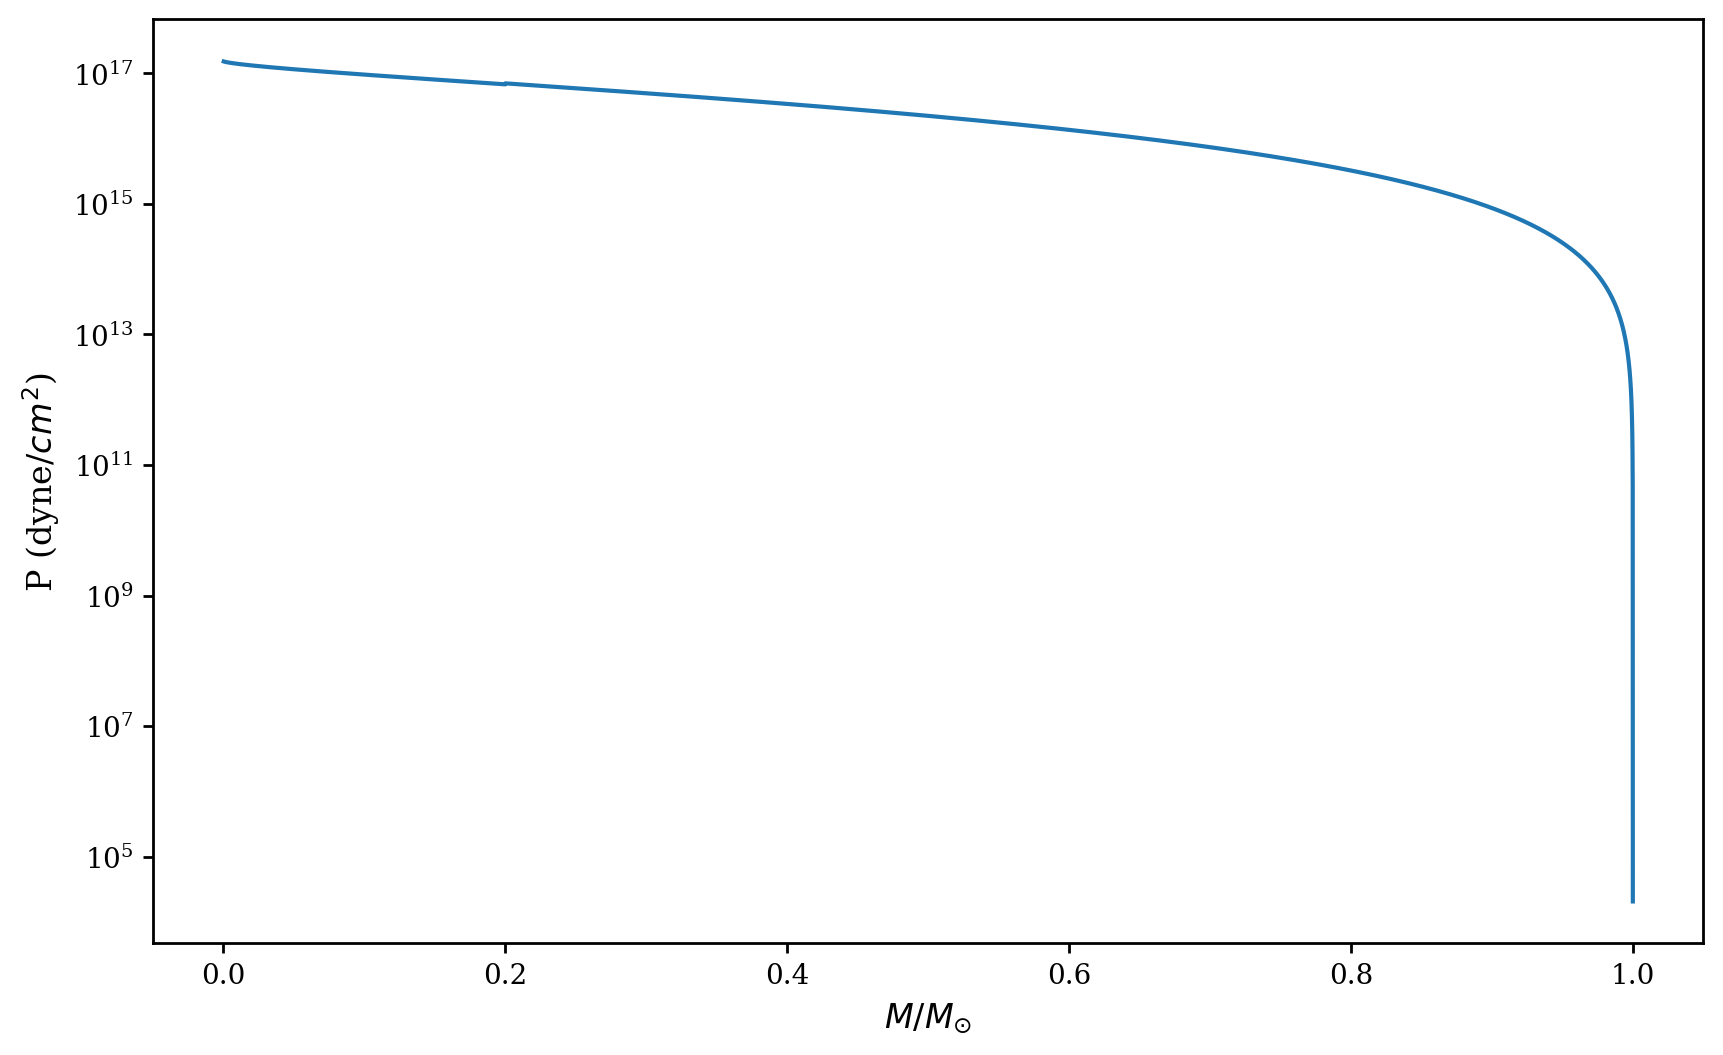

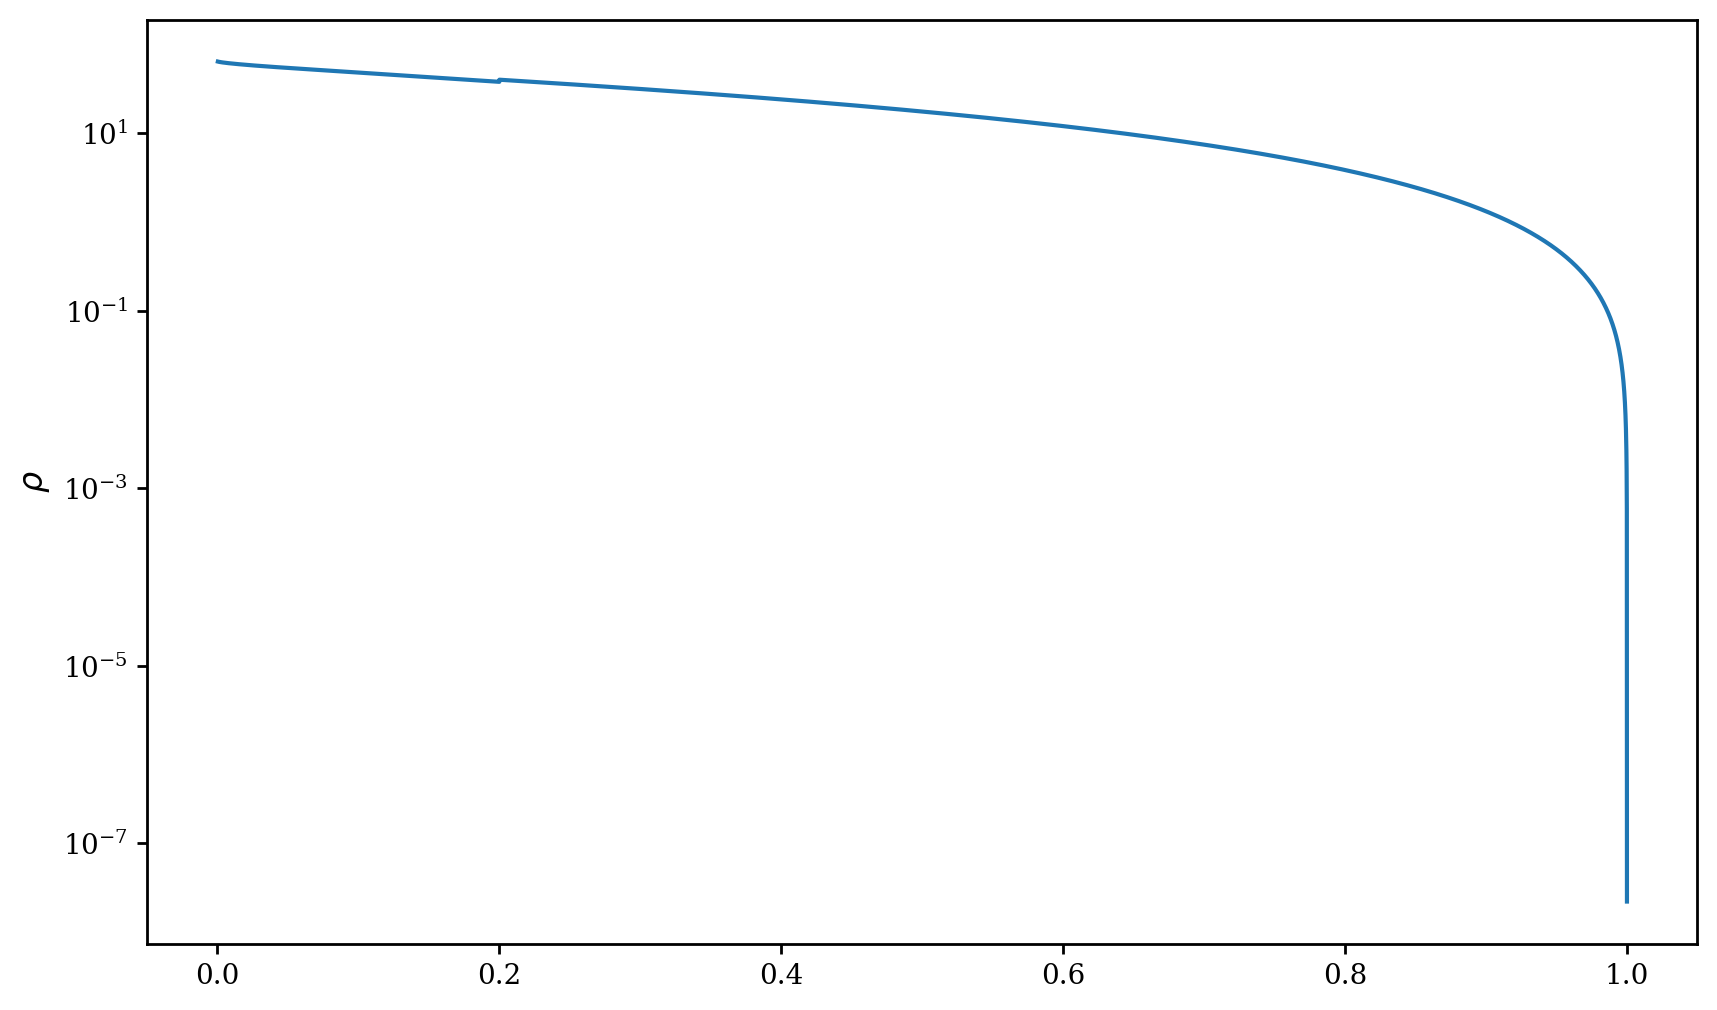

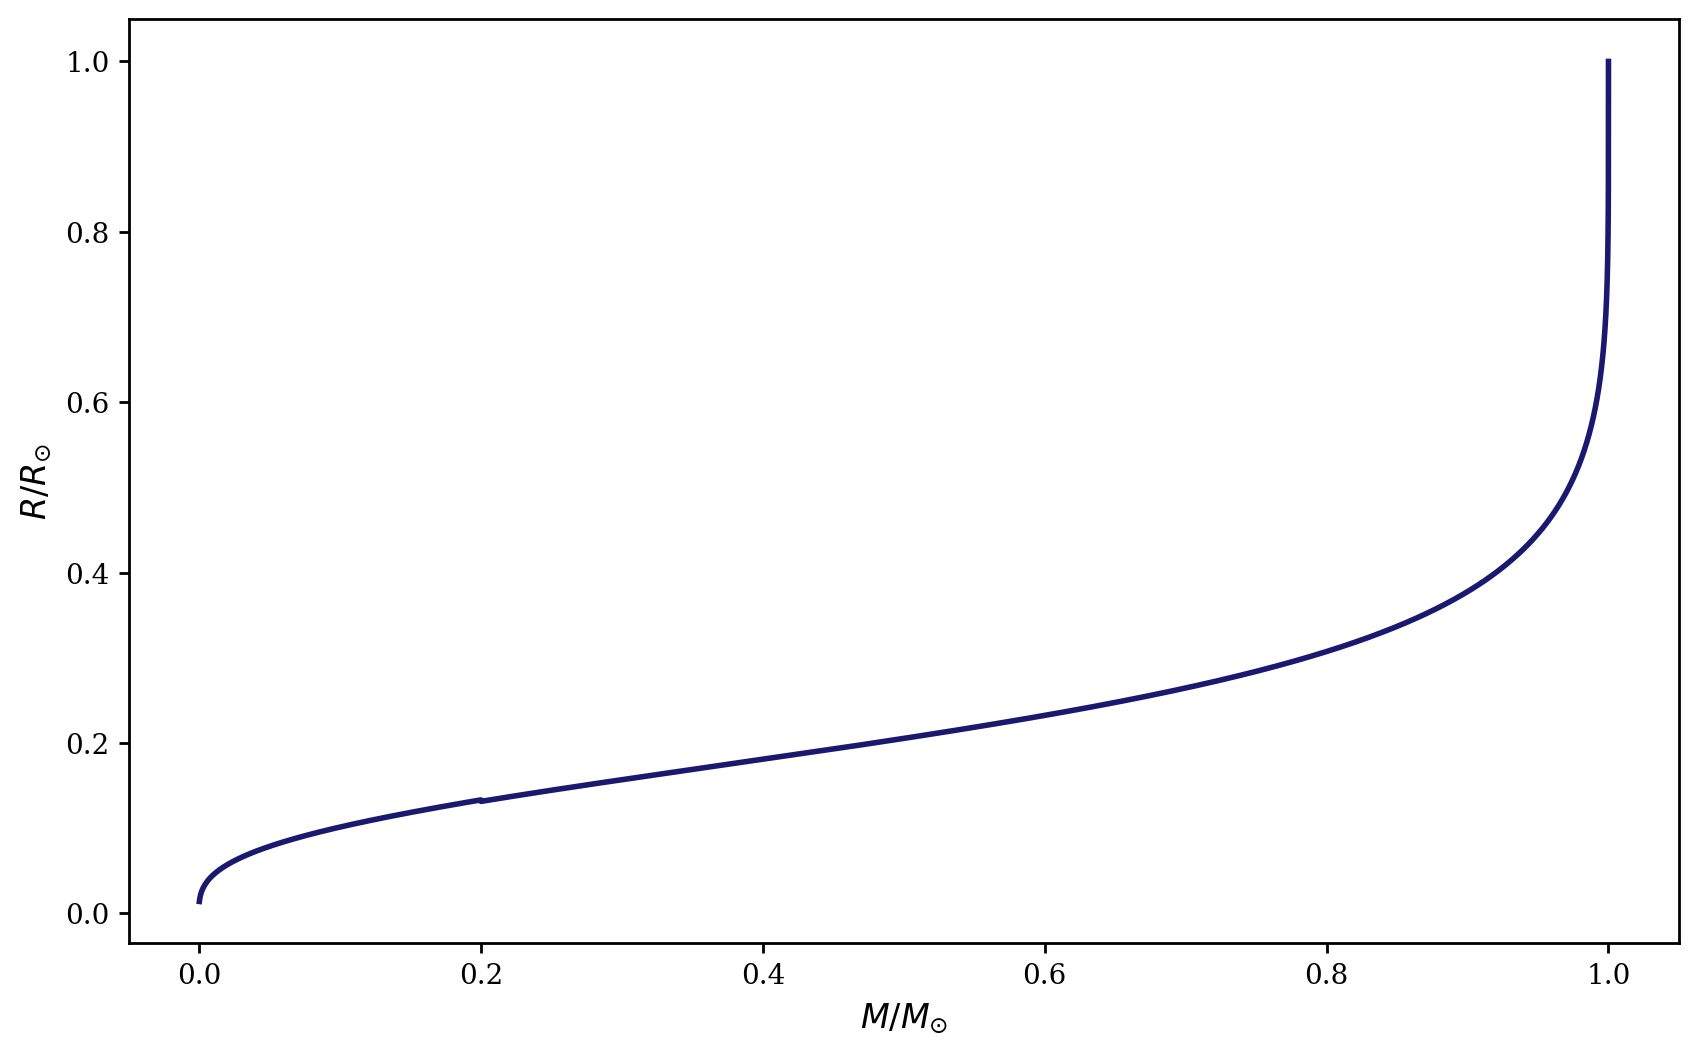

/var/folders/cj/75y0_v4d4db3m414f6517p_00000gn/T/ipykernel_66667/2403699469.py:32: RuntimeWarning: divide by zero encountered in log10
  plt.plot(-np.log10(1-M_values/Mstar), L_values)


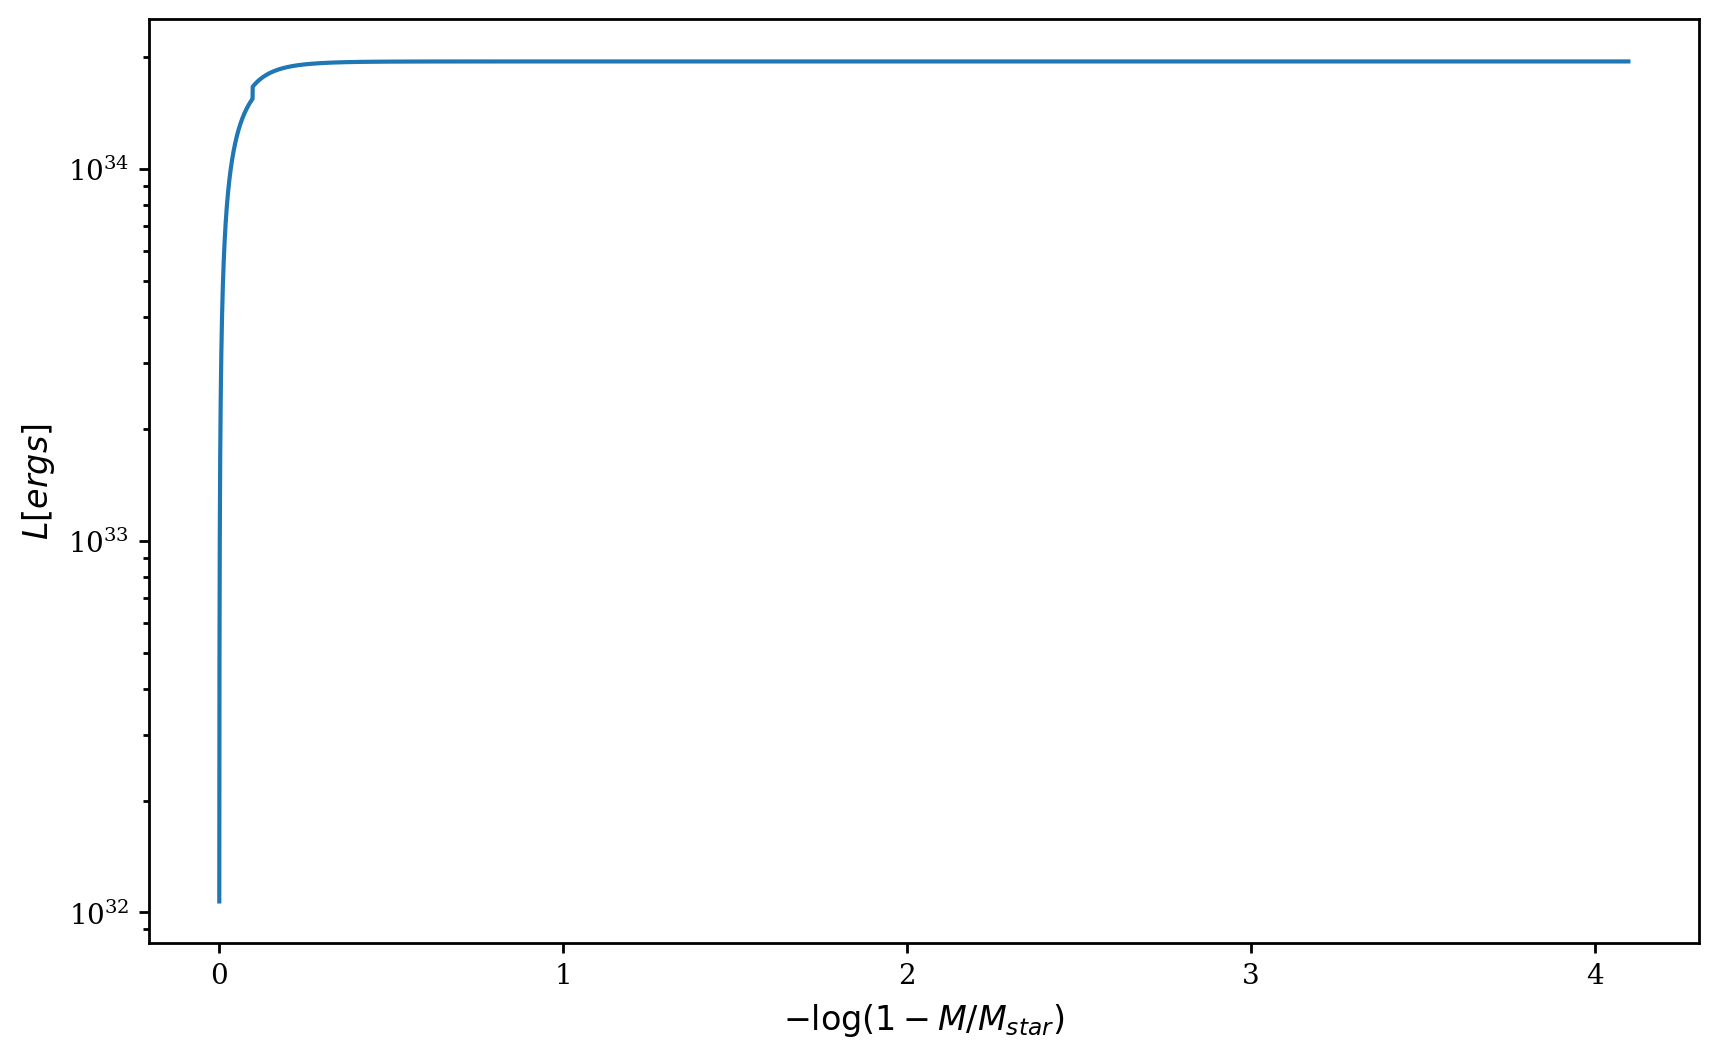

In [67]:
# Extract interior mass regions where star is convective or radiative
transition_mass = M_values[np.where(convective_bool == False)[0][-1]]
print(transition_mass)
transition_radius = R_values[np.where(convective_bool == False)[0][-1]]
print(transition_radius)

#abscissa = -np.log10(1-M_values/Mstar)
abscissa = M_values/Mstar
plt.plot(abscissa, P_values)
# plt.xscale('log')
plt.yscale('log')
#plt.xlabel(r"$-\log(1-M_r/M_{\odot})$")
plt.xlabel(r"$M/M_{\odot}$")
plt.ylabel(r"P (dyne/$cm^2$)")
#plt.xlim(0.08, 0.12)
plt.show()

plt.plot(abscissa, rho_values)
plt.yscale('log')
#plt.xlabel(r"$-\log(1-M_r/M_{\odot})$")
plt.ylabel(r"$M/M_{\odot}$")
plt.ylabel(r"$\rho$")
plt.show()

plt.plot(M_values/Mstar, R_values/R_values[-1], linewidth = 2, color = "midnightblue", label = r"$R(M)$")
#plt.xscale('log')
plt.ylabel("$R/R_{\odot}$")
plt.xlabel("$M/M_{\odot}$")
plt.show()


plt.plot(-np.log10(1-M_values/Mstar), L_values)
plt.yscale('log')
#plt.xlabel("$R/R_{\odot}$")
plt.xlabel("$-\log(1-M/M_{star})$")
#plt.xscale('log')
plt.ylabel("$L [ergs]$")
plt.show()

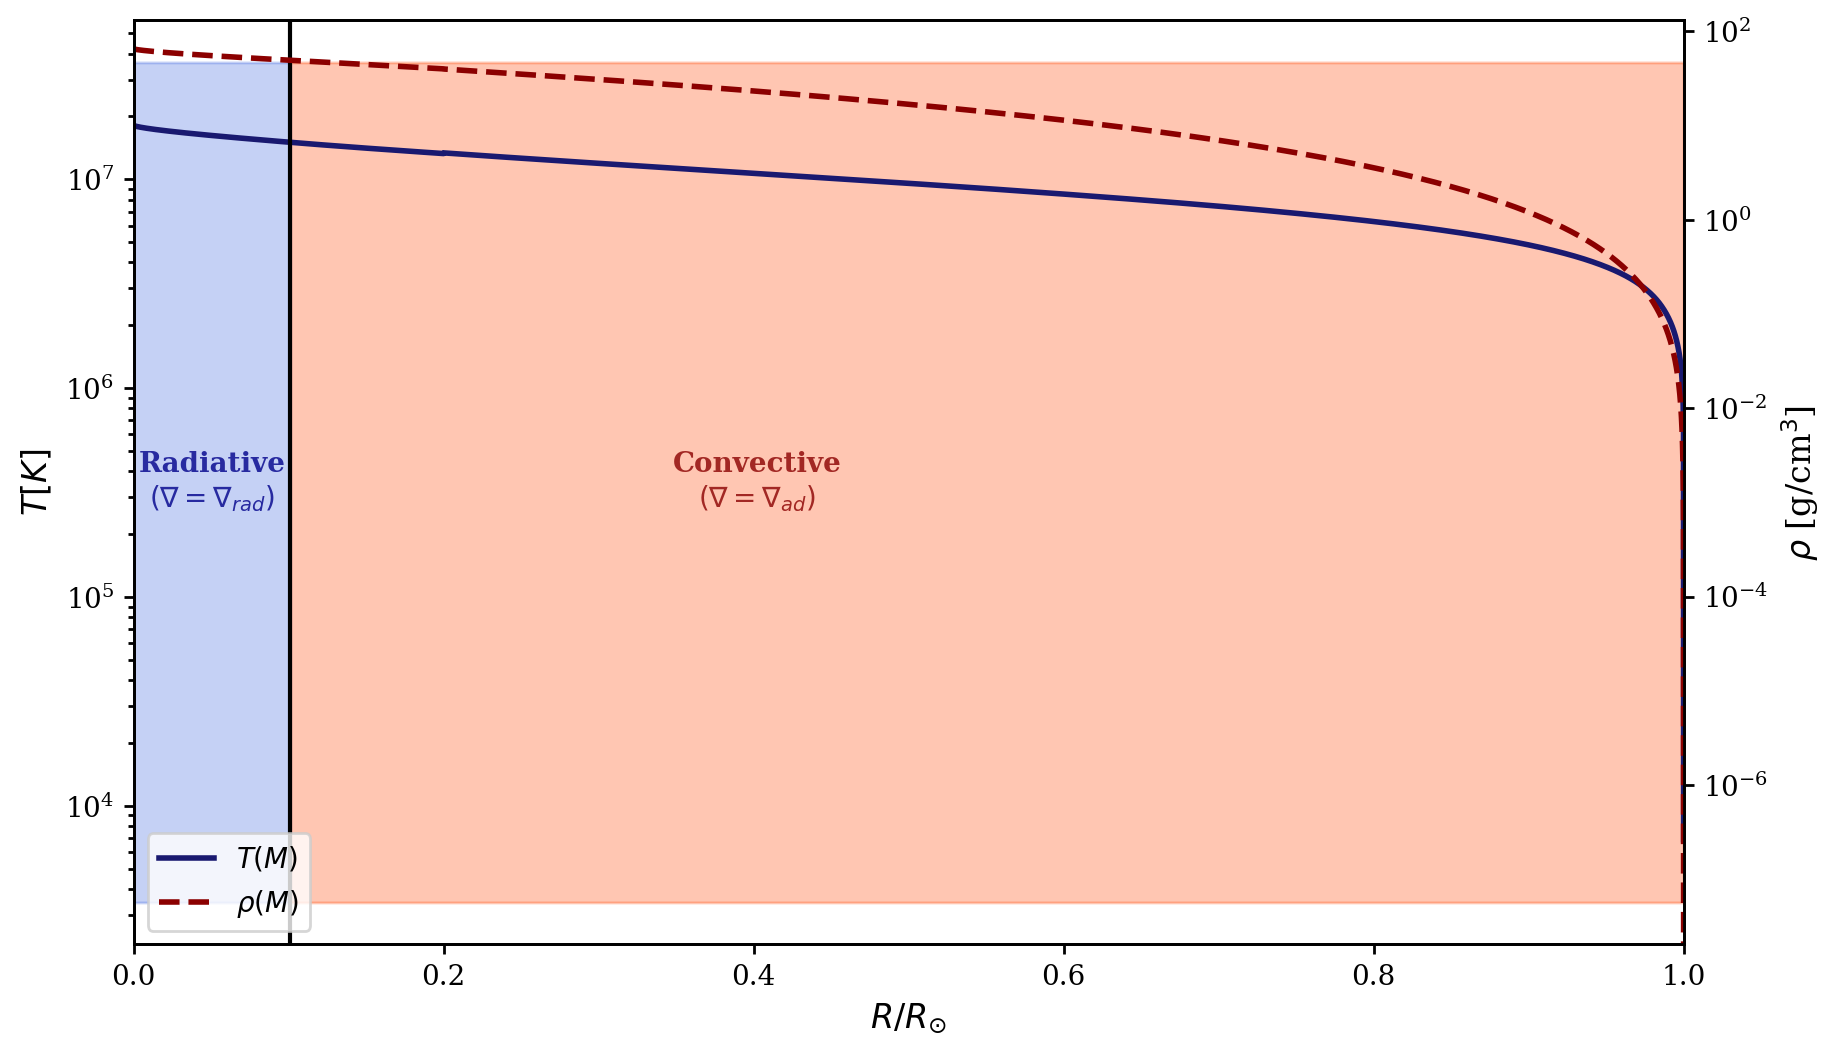

In [62]:
# Plot of temperature, density, and convective regions
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.plot(M_values/Mstar, T_values, color = "midnightblue", linewidth = 2, label = r"$T(M)$")
ax2.plot(x, rho_values, color='darkred', linewidth=2, linestyle='--', label=r'$\rho(M)$')
ax2.set_ylabel(r"$\rho$ [g/cm$^3$]", fontsize=12, color="black")
ax2.tick_params(axis='y', labelcolor="black")
ax2.set_yscale('log')
ax2.set_ylim(rho_values.min(), rho_values.max() * 2.0)
#x = np.linspace(M_values.min()/Mstar, M_values.max()*1.2/Mstar, 19999)
x = M_values/Mstar
ax1.fill_between(x, T_values.min()*0.5, T_values.max()*2.0, where=convective_bool, alpha=0.3, color='orangered')
ax1.fill_between(x, T_values.min()*0.5, T_values.max()*2.0, where=~convective_bool, alpha=0.3, color='royalblue')
ax1.axvline(transition_mass/Mstar, color = 'black')
# Labeling
radiative_indices = np.where(~convective_bool)[0]
radiative_center_idx = radiative_indices[len(radiative_indices)//2]
x_rad = x[radiative_center_idx]
convective_indices = np.where(convective_bool)[0]
convective_center_idx = convective_indices[len(convective_indices)//2]
x_conv = x[convective_center_idx]
y_label = np.sqrt(T_values.min() * T_values.max())
ax1.text(x_rad, y_label, 'Radiative\n' + r'$(\nabla = \nabla_{rad})$', 
         fontsize=10, ha='center', va='center', color='darkblue',
         fontweight='bold', alpha=0.8)

ax1.text(x_conv, y_label, 'Convective\n' + r'$(\nabla = \nabla_{ad})$', 
         fontsize=10, ha='center', va='center', color='darkred',
         fontweight='bold', alpha=0.8)
ax1.set_yscale('log')
ax1.set_xlabel("$R/R_{\odot}$")
ax1.set_ylabel("$T [K]$")
ax1.set_xlim(0, M_values.max()/Mstar)
#ax1.set_ylim(0, rho_values.max())

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left", fontsize=10)
plt.show()

# Plot the mass and o

### MESA Stellar Structure Calculations
Here we collect the properties of the same $1.6M_{\odot}$ ZAMS star with solar composition calculated using the state-of-the-art MESA code. We will compare these values to the those calculated with our model here.